<a href="https://colab.research.google.com/github/RuchiKalkandha/Vision-Transformers-and-multimodal-LLMs/blob/main/Coding_VAE_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#imports

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#creating batches

BATCH_SIZE = 128

data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(
    root = "./data",
    train = True,
    transform = data_transform,
    download = True
)

train_loader = DataLoader(dataset = train_dataset, batch_size = BATCH_SIZE, shuffle = True)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.56MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 55.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.3MB/s]


In [ ]:
#coding the VAE class

latent_dim = 128

class VAE(nn.Module):
  def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
    super().__init__()

    #Encoder
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    #Decoder
    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, input_dim)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encode(self, x):
    h = self.relu(self.fc1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

  def decode(self, z):
    h = self.relu(self.fc2(z))
    out = self.sigmoid(self.fc3(h))
    return out

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_reconstructed = self.decode(z)
    return x_reconstructed, mu, logvar

In [ ]:
#coding the loss

def vae_loss(recon_x, x, mu, logvar):
  # recon_loss = nn.functional.mse_loss(recon_x, x)
  recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction="sum")
  kl_loss = 0.5*torch.sum(mu.pow(2) + logvar.exp() - logvar - 1)

  return recon_loss + kl_loss

In [ ]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
epochs = 15

model.train()
for epoch in range(epochs):
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/15], Loss: 303.3474
Epoch [2/15], Loss: 270.0679
Epoch [3/15], Loss: 260.1411
Epoch [4/15], Loss: 254.0335
Epoch [5/15], Loss: 250.5082
Epoch [6/15], Loss: 248.4969
Epoch [7/15], Loss: 247.0232
Epoch [8/15], Loss: 246.0444
Epoch [9/15], Loss: 245.2478
Epoch [10/15], Loss: 244.6088
Epoch [11/15], Loss: 244.0931
Epoch [12/15], Loss: 243.6939
Epoch [13/15], Loss: 243.2713
Epoch [14/15], Loss: 242.9322
Epoch [15/15], Loss: 242.6703


In [ ]:
# epochs = 15

# model.train()

# for epoch in range(epochs):
#   total_loss = 0

#   for x, _ in (train_loader):
#     x = x.view(-1,784).to(device)
#     optimizer.zero_grad()
#     x_recon, mu, logvar = model(x)
#     loss = vae_loss(x_recon, x, mu, logvar)
#     loss.backward()
#     optimizer.step()
#     total_loss = total_loss + loss.item()

#   avg_loss = total_loss/len(train_loader.dataset)

#   print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


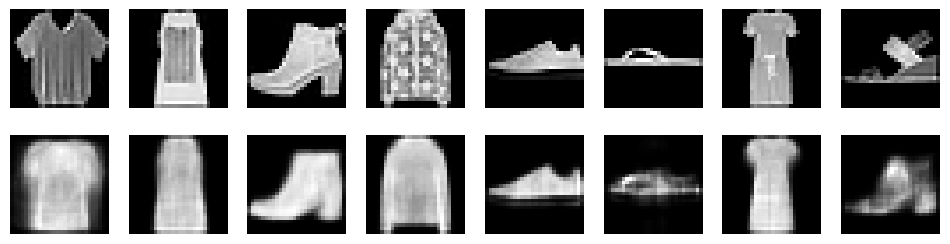

In [ ]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)

    x_recon, _, _ = model(x)

    x = x.cpu()
    x_recon = x_recon.cpu()

    n = 8
    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].view(28, 28), cmap="gray")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recon[i].view(28, 28), cmap="gray")
        plt.axis("off")

    plt.show()

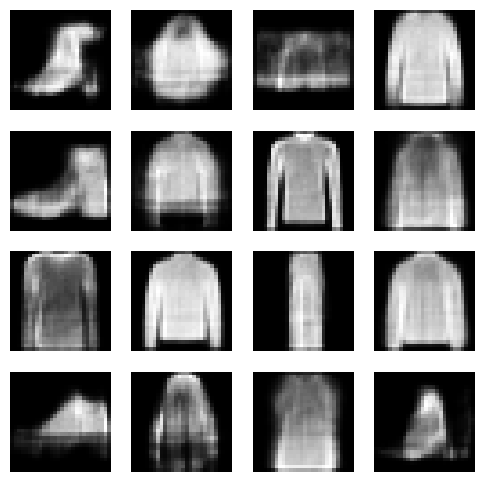

In [ ]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decode(z).cpu()

    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(samples[i].view(28, 28), cmap="gray")
        plt.axis("off")
    plt.show()